In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
import warnings

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
warnings.filterwarnings('ignore')

# import func_gcp as fun_gcp

In [2]:
# query = '''
# select  * 
# from spsa-operaciones-seg-sd.dst_gestion_operativa.cv_venta
# where year >= 2025
# '''

# df_venta = fun_gcp.read_query(query)
# df_venta.to_parquet(r"parquet\cv_venta.parquet")

In [3]:
# query = '''
# select * from spsa-operaciones-seg-sd.dst_gestion_operativa.bsc_local_atributos
# '''

# df = fun_gcp.read_query(query)
# df.to_parquet(r"parquet\bsc_local_atributos.parquet")

In [ ]:
# query_dax = """EVALUATE 'BD_HrsReal'"""
# df = fun_gcp.ejecutar_dax(query_dax)
# df.columns = df.columns.str.extract(r"\[(.*?)\]", expand=False)
# df.to_parquet(r"parquet\BD_HrsReal.parquet")

In [42]:
df_venta = pd.read_parquet(r"parquet\cv_venta.parquet")
df_local = pd.read_parquet(r"parquet\bsc_local_atributos.parquet")
df_horas = pd.read_parquet(r"parquet\BD_HrsReal.parquet")

In [5]:
df_venta.groupby(["tipo_venta", "sub_tipo_Venta"])["venta"].sum()


tipo_venta       sub_tipo_Venta      
Delivery         Jokr APP                3.482551e+06
                 Jokr Ecomm              6.388787e+04
                 Jokr Web - Ecommerce    2.099178e+05
Last Mile        Agora Shop              1.330592e+08
Venta CNegocio   Venta CNegocio          1.706203e+08
Venta Ecommerce  Agora OPS               1.067324e+08
                 Ecommerce               3.046840e+08
                 Home Delivery           1.077748e+07
                 Store Withdrawal        1.350229e+07
Venta POS        Direct Sale             2.672923e+08
                 Ecommerce               0.000000e+00
                 Venta POS               8.466002e+09
Name: venta, dtype: float64

In [6]:
df_porcentaje = (df_venta.groupby(["tipo_venta", "sub_tipo_Venta"])["venta"].sum() / df_venta["venta"].sum()) * 100
df_porcentaje

tipo_venta       sub_tipo_Venta      
Delivery         Jokr APP                 0.036750
                 Jokr Ecomm               0.000674
                 Jokr Web - Ecommerce     0.002215
Last Mile        Agora Shop               1.404107
Venta CNegocio   Venta CNegocio           1.800471
Venta Ecommerce  Agora OPS                1.126293
                 Ecommerce                3.215178
                 Home Delivery            0.113729
                 Store Withdrawal         0.142483
Venta POS        Direct Sale              2.820602
                 Ecommerce                0.000000
                 Venta POS               89.337497
Name: venta, dtype: float64

In [7]:
df_venta["periodo"] = df_venta["year"].astype(str) + df_venta["mes"].astype(str).str.zfill(2)
df_venta1 = df_venta.groupby(["periodo", "codigo_local"])["venta"].sum().reset_index()

In [8]:
df_venta1

,periodo,codigo_local,venta
0,202501,1198,2392014.61
1,202501,1199,5585774.18
2,202501,1593,5440157.24
3,202501,P001,4731754.58
4,202501,P010,11805710.47
...,...,...,...
2032,202606,V140,163020.12
2033,202606,V254,0.00
2034,202606,V290,21254.65
2035,202606,X209,33054.88


In [9]:
df_local1 = df_local[["codigo_local", "formato", "ubicacion", "nombre", "cluster", "m2"]]

In [10]:
dff = df_venta1.merge(df_local1, on="codigo_local", how="left")

In [11]:
print("formato", dff["formato"].unique())
print("ubicacion", dff["ubicacion"].unique())
print("cluster", dff["cluster"].unique())


formato ['PLAZA VEA' 'PLAZA VEA SUPER' 'PLAZA VEA EXPRESS' 'VIVANDA']
ubicacion ['Provincia' 'Lima + Callao']
cluster ['B2' 'A2' 'C3' 'A3' 'B3' 'B1' 'A1' 'C2' 'EX' 'C1' 'E1' 'V1' 'V2' 'V4']


In [12]:
dff.groupby(["formato"])["codigo_local"].nunique()

formato
PLAZA VEA            77
PLAZA VEA EXPRESS     5
PLAZA VEA SUPER      25
VIVANDA               9
Name: codigo_local, dtype: int64

In [13]:
dff.groupby(["formato","cluster"])["codigo_local"].nunique()

formato            cluster
PLAZA VEA          A2          3
                   A3         10
                   B1          1
                   B2         16
                   B3         21
                   C2          7
                   C3         18
                   E1          1
PLAZA VEA EXPRESS  EX          5
PLAZA VEA SUPER    A1          2
                   A2          4
                   B1          7
                   B2          1
                   C1         10
                   C2          1
VIVANDA            V1          7
                   V2          1
                   V4          1
Name: codigo_local, dtype: int64

In [14]:
dff1 = dff[dff["venta"]!=0]
dff1["year"] = dff1["periodo"].str[0:4]
dff1

,periodo,codigo_local,venta,formato,ubicacion,nombre,cluster,m2,year
0,202501,1198,2392014.61,PLAZA VEA,Provincia,Cusco Wanchaq-PVH,B2,2227.0,2025
1,202501,1199,5585774.18,PLAZA VEA,Lima + Callao,San Miguel - PVH,A2,2854.0,2025
2,202501,1593,5440157.24,PLAZA VEA,Lima + Callao,SJL Aventura - PVH,C3,4136.0,2025
3,202501,P001,4731754.58,PLAZA VEA,Lima + Callao,Los Olivos - PVH,B2,2315.0,2025
4,202501,P010,11805710.47,PLAZA VEA SUPER,Lima + Callao,Caminos del Inca - PVS,A2,3507.0,2025
...,...,...,...,...,...,...,...,...,...
2031,202606,V116,159758.82,VIVANDA,Lima + Callao,Javier Prado - VIV,V1,1152.0,2026
2032,202606,V140,163020.12,VIVANDA,Lima + Callao,Libertadores - VIV,V1,1167.0,2026
2034,202606,V290,21254.65,VIVANDA,Lima + Callao,Asia - VIV,V2,2298.0,2026
2035,202606,X209,33054.88,PLAZA VEA EXPRESS,Lima + Callao,Bolognesi - PVE,EX,343.0,2026


In [67]:
df_horas['FECHA'] = pd.to_datetime(df_horas['FECHA'], errors='coerce')
df_horas["periodo"] = (df_horas['FECHA'].dt.year.astype(str) + df_horas['FECHA'].dt.month.astype(str).str.zfill(2))
factor_dia = 192 / 28

cant_dias_mes = df_horas["FECHA"].dt.days_in_month
factor_mes = factor_dia * cant_dias_mes
df_horas["JEQv2"] = np.where(df_horas["_Tipo"]!="Adm", df_horas["HRS_REAL"] / factor_mes, 0)
df_horas["codigo_local"] = df_horas["_Cod_local_v2"]

In [87]:
df_horas1 = df_horas.groupby(["periodo", "codigo_local"])["JEQv2"].sum().reset_index()

In [89]:
dff2 = dff1[dff1["periodo"]<="202605"].merge(df_horas1, on=['codigo_local', 'periodo'], how="left")


In [91]:
dff2

,periodo,codigo_local,venta,formato,ubicacion,nombre,cluster,m2,year,JEQv2
0,202501,1198,2392014.61,PLAZA VEA,Provincia,Cusco Wanchaq-PVH,B2,2227.0,2025,32.683555
1,202501,1199,5585774.18,PLAZA VEA,Lima + Callao,San Miguel - PVH,A2,2854.0,2025,76.168138
2,202501,1593,5440157.24,PLAZA VEA,Lima + Callao,SJL Aventura - PVH,C3,4136.0,2025,54.497023
3,202501,P001,4731754.58,PLAZA VEA,Lima + Callao,Los Olivos - PVH,B2,2315.0,2025,53.504321
4,202501,P010,11805710.47,PLAZA VEA SUPER,Lima + Callao,Caminos del Inca - PVS,A2,3507.0,2025,118.137890
...,...,...,...,...,...,...,...,...,...,...
1886,202605,V116,2960324.58,VIVANDA,Lima + Callao,Javier Prado - VIV,V1,1152.0,2026,55.093293
1887,202605,V140,2782428.31,VIVANDA,Lima + Callao,Libertadores - VIV,V1,1167.0,2026,47.969711
1888,202605,V290,768134.80,VIVANDA,Lima + Callao,Asia - VIV,V2,2298.0,2026,21.015477
1889,202605,X209,539279.90,PLAZA VEA EXPRESS,Lima + Callao,Bolognesi - PVE,EX,343.0,2026,10.128219


In [92]:
dff3 = dff2[~dff2["JEQv2"].isnull()]

In [119]:
dff_pvh = dff3[dff3["formato"]=="PLAZA VEA"]
dff_pvh["cat_ubicacion"] = np.where(dff_pvh["ubicacion"]=="Provincia",1 ,2)

dic_cluter_pvh = {  'A3':8, 
                    'A2':7,
                    'B3':6, 
                    'B2':5,
                    'B1':4,
                    'C3':3,
                    'C2':2,
                    'E1':1,
                    }
dff_pvh["cat_cluster"] = dff_pvh["cluster"].map(dic_cluter_pvh)

dff_pvh["cluster"].unique()


df_cluster = dff_pvh[["venta", "cat_ubicacion", "cat_cluster", "m2", "JEQv2"]]

In [120]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Preparación de features y escalado matricial vectorizado
features = ["venta", "cat_ubicacion", "cat_cluster", "m2", "JEQv2"]
peso_venta = 2

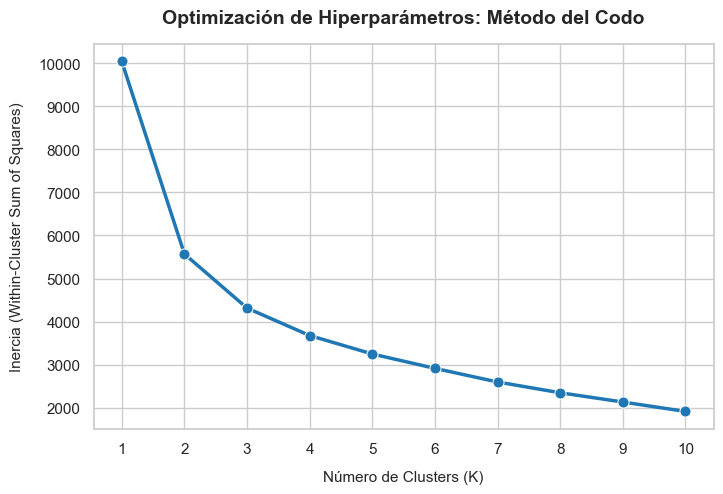

In [121]:


X = df_cluster[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# Aplicar la ponderación en el espacio de características

X_scaled_df["venta"] = X_scaled_df["venta"] * peso_venta

# 2. Búsqueda iterativa del hiperparámetro K (Inercia / WCSS)
inercia_valores = []
k_rango = range(1, 11)

for k in k_rango:
    # n_init='auto' optimiza la inicialización según la versión de sklearn
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    inercia_valores.append(kmeans.inertia_)

# 3. Estructuración de métricas para la visualización
df_elbow = pd.DataFrame({"K": list(k_rango), "Inercia": inercia_valores})

# 4. Construcción del gráfico de optimización utilizando Seaborn
sns.set_theme(style="whitegrid")

# Inicializar gráfico sin llamar a .figure() para respetar el entorno del notebook
fig, ax = plt.subplots(figsize=(8, 5))

# Plot lineal con marcadores para identificar el punto de inflexión geométrico
sns.lineplot(
    data=df_elbow,
    x="K",
    y="Inercia",
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="#1f77b4",
    ax=ax,
)

# Configuración de etiquetas y jerarquía visual del canvas
ax.set_title(
    "Optimización de Hiperparámetros: Método del Codo",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Número de Clusters (K)", fontsize=11, labelpad=10)
ax.set_ylabel("Inercia (Within-Cluster Sum of Squares)", fontsize=11, labelpad=10)
ax.set_xticks(list(k_rango))

# Guardado asíncrono y renderizado limpio del objeto
plt.savefig("metodo_codo_clusters.png", dpi=300, bbox_inches="tight")

In [122]:
num_clusters = 3

X = df_cluster[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df["venta"] = X_scaled_df["venta"] * peso_venta
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df_cluster["cluster_asignado"] = kmeans.fit_predict(X_scaled_df)

In [123]:
# Agrupamiento y cálculo de medias por cluster
tabla_perfiles = (
    df_cluster.groupby("cluster_asignado")[features]
    .mean()
    .round(2)
).reset_index()

# Mostrar la tabla de perfiles en el notebook
tabla_perfiles

,cluster_asignado,venta,cat_ubicacion,cat_cluster,m2,JEQv2
0,0,9593460.81,1.54,5.95,4344.82,89.86
1,1,3495779.41,1.62,3.62,2723.09,45.06
2,2,5954205.63,1.56,5.14,4014.86,63.26


In [124]:
dff_pvh["cluster_asignado"] = df_cluster["cluster_asignado"]

In [125]:
dff_pvh

,periodo,codigo_local,venta,formato,ubicacion,nombre,cluster,m2,year,JEQv2,cat_ubicacion,cat_cluster,cluster_asignado
0,202501,1198,2392014.61,PLAZA VEA,Provincia,Cusco Wanchaq-PVH,B2,2227.0,2025,32.683555,1,5,1
1,202501,1199,5585774.18,PLAZA VEA,Lima + Callao,San Miguel - PVH,A2,2854.0,2025,76.168138,2,7,2
2,202501,1593,5440157.24,PLAZA VEA,Lima + Callao,SJL Aventura - PVH,C3,4136.0,2025,54.497023,2,3,2
3,202501,P001,4731754.58,PLAZA VEA,Lima + Callao,Los Olivos - PVH,B2,2315.0,2025,53.504321,2,5,1
5,202501,P037,4982684.24,PLAZA VEA,Lima + Callao,Jockey Plaza - PVH,A3,5675.0,2025,66.080894,2,8,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1877,202605,SO02,10024530.75,PLAZA VEA,Provincia,Pucallpa - PVO,B3,4112.0,2026,82.771284,1,6,0
1878,202605,SO03,8990149.64,PLAZA VEA,Provincia,Huanuco - PVO,B3,3638.0,2026,72.746935,1,6,0
1879,202605,SO04,7825249.22,PLAZA VEA,Provincia,Jaen - PVO,C3,3976.0,2026,55.089435,1,3,2
1880,202605,SO05,7650769.31,PLAZA VEA,Provincia,Tarapoto - PVO,C3,3961.0,2026,77.646559,1,3,2


In [137]:
dff_pvh1 = dff_pvh.groupby(["nombre", "cluster_asignado"]).size().reset_index(name="cant")

In [141]:
dff_pvh_unicos = (
    dff_pvh1.sort_values(by="cant", ascending=False)
    .drop_duplicates(subset=["nombre"], keep="first")
    .sort_index()  # Opcional: Reordenar por el índice original si deseas mantener el orden inicial
)

dff_pvh_unicos["cluster_final"] = dff_pvh_unicos["cluster_asignado"]

In [144]:
dff_pvh_unicos

,nombre,cluster_asignado,cant,cluster_final
0,Acho - PVH,1,17,1
1,Alfonso Ugarte - PVH,1,17,1
3,Arequipa - PVH,2,15,2
4,Ate - PVH,2,17,2
5,Barranca - PVH,1,17,1
...,...,...,...,...
112,Tumbes - PVH,2,16,2
113,Universitaria - PVH,1,12,1
116,Valle Hermoso - PVH,2,11,2
118,Ventanilla - PVH,2,15,2


In [146]:
dff_pvh.merge(dff_pvh_unicos[["nombre", "cluster_final"]], on="nombre", how="left").to_excel("revisar_01.xlsx", index=False)